In [1]:
# Ejecutar si se trabaja en maquina local
MAIN_ROUTE = '..'

In [ ]:
# Ejecutar si se trabaja en google colab
from google.colab import drive
drive.mount('/content/drive')

MAIN_ROUTE = '/content/drive/MyDrive/Proyecto-de-Investigacion'

In [3]:
import logging

# Logging mínimo
logging.basicConfig(
    filename=MAIN_ROUTE+"/logs/05_RESULTADOS_01_RAG.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True
)

In [5]:
import numpy as np

logging.info("[Inicio] de concatenacion de embedings")
embeddings = np.load(MAIN_ROUTE+"/embeddings/CHUNK_PRODUCTO.npy")
embeddings = np.concatenate((embeddings,np.load(MAIN_ROUTE+"/embeddings/CHUNK_FICHA.npy")))
embeddings = np.concatenate((embeddings,np.load(MAIN_ROUTE+"/embeddings/CHUNK_DESCRIPCION.npy")))
embeddings = np.concatenate((embeddings,np.load(MAIN_ROUTE+"/embeddings/CHUNK_CARACTERISTICAS.npy")))
embeddings = np.concatenate((embeddings,np.load(MAIN_ROUTE+"/embeddings/CHUNK_OBSERVACIONES.npy")))
embeddings = np.concatenate((embeddings,np.load(MAIN_ROUTE+"/embeddings/CHUNK_RECOMENDACIONES.npy")))

len(embeddings)
logging.info("[Fin] de concatenacion de embedings, total: "+str(len(embeddings)))

In [9]:
import faiss
# Crear índice FAISS
index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(embeddings)

In [ ]:
from sentence_transformers import SentenceTransformer

# Cargar modelo localmente
logging.info("[Inicio] Carga de modelo (all-MiniLM-Lx-v2)")
#embedder = SentenceTransformer(MAIN_ROUTE+"/modelos/all-MiniLM-L6-v2")
embedder = SentenceTransformer(MAIN_ROUTE+"/modelos/all-MiniLM-L12-v2")
logging.info("[Fin] Carga de modelo (all-MiniLM-Lx-v2)") 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def responder_pregunta_rag(pregunta, k=10):
    # Embed la pregunta
    pregunta_emb = embedder.encode([pregunta], convert_to_numpy=True)

    # Buscar los k textos más cercanos
    distancias, indices = index.search(pregunta_emb, k)
    print(distancias)
    print(indices)


In [11]:
responder_pregunta_rag('necesito una refrigeradora')

Batches: 100%|██████████| 1/1 [00:00<00:00,  2.90it/s]

[[0.48415554 0.51201236 0.51201236 0.51201236 0.51201236 0.51201236
  0.51201236 0.51201236 0.51201236 0.5710421 ]]
[[176543 224699 224700 224701 224702 224703 224704 227696 227697 115258]]


In [16]:
import pandas as pd

df = pd.read_csv(MAIN_ROUTE+"/data/processed/productos_corpus.csv",delimiter=",")
logging.info("Se carga el corpus csv")

# Muestra de 500 chunks

In [21]:
sentences = df['CHUNK_PRODUCTO'].sample(n=500).astype(str).tolist()

In [22]:
sentences

['taco dark de la marca kantu del area de pisos y revestimientos para los decorados de la linea listelos de procedencia nacional',
 'i&o-mantel poliester con diseño 150x250 cm medité de la marca orange del area de tendencias para los colecciones de la linea cocina de procedencia importado',
 'reflector 30w lf ip65 de la marca bellalux del area de iluminacion para los iluminacion exterior de la linea reflectores de procedencia nacional',
 'lampara de mesa cinema de la marca orange del area de iluminacion para los iluminacion decorativa de la linea lamparas de mesa de procedencia importado',
 'one piece ocean blanco de la marca vainsa del area de baños para los sanitarios de la linea one piece de procedencia nacional',
 'bola para bebida dorada c.dorada de la marca orange del area de tendencias para los navidad de la linea menaje navidad de procedencia importado',
 'ultra cover2x granito satinado 340gr de la marca rust oleum del area de pinturas para los esmaltes, barnices y solventes de

Batches: 100%|██████████| 16/16 [00:00<00:00, 16.91it/s]


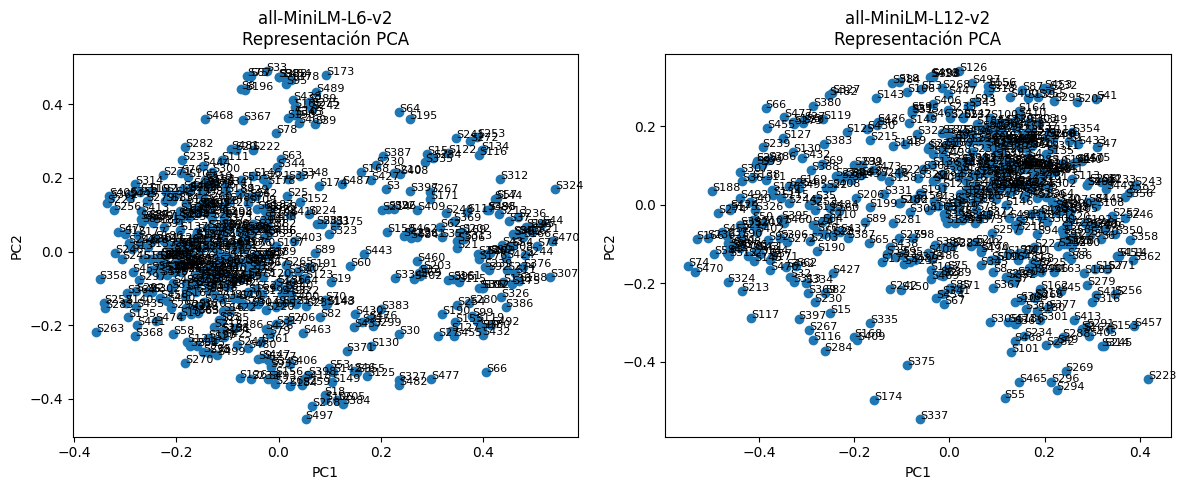

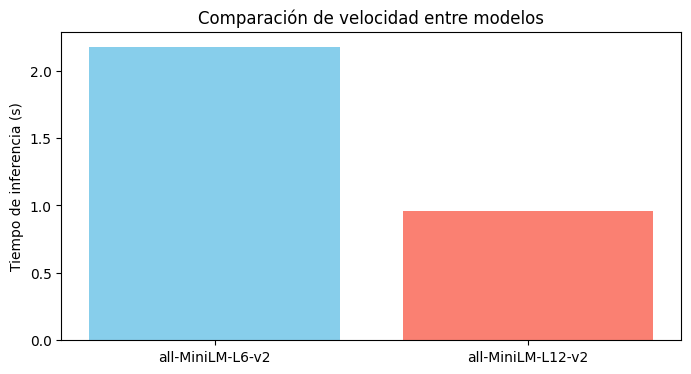

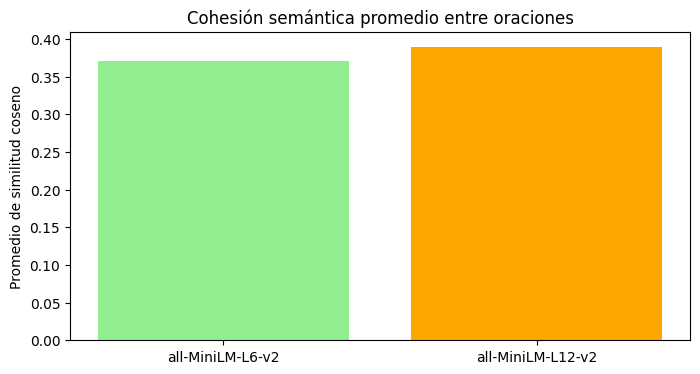

Modelo: all-MiniLM-L6-v2
 - Tiempo de inferencia: 2.176 s
 - Similitud promedio:  0.3712
----------------------------------------
Modelo: all-MiniLM-L12-v2
 - Tiempo de inferencia: 0.957 s
 - Similitud promedio:  0.3893
----------------------------------------


In [ ]:
# ============================================
# Comparación: all-MiniLM-L12-v2 vs all-MiniLM-L6-v2
# ============================================

from sentence_transformers import SentenceTransformer, util
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Definir modelos y conjunto de oraciones de prueba
# ------------------------------------------------------------

models = {
    "all-MiniLM-L6-v2": SentenceTransformer(MAIN_ROUTE+"/modelos/all-MiniLM-L6-v2"),
    "all-MiniLM-L12-v2": SentenceTransformer(MAIN_ROUTE+"/modelos/all-MiniLM-L12-v2")
}

# ------------------------------------------------------------
# 2. Calcular embeddings y tiempo de inferencia
# ------------------------------------------------------------
times = {}
embeddings = {}

for name, model in models.items():
    start = time.time()
    embeddings[name] = model.encode(sentences, convert_to_tensor=True, show_progress_bar=True)
    times[name] = time.time() - start

# ------------------------------------------------------------
# 3. Evaluar similitud semántica entre oraciones
# ------------------------------------------------------------
def avg_similarity(embs):
    sim = util.cos_sim(embs, embs).cpu().numpy()
    # Tomar promedio de similitudes fuera de la diagonal
    mask = ~np.eye(sim.shape[0], dtype=bool)
    return sim[mask].mean()

similarities = {name: avg_similarity(emb) for name, emb in embeddings.items()}

# ------------------------------------------------------------
# 4. Visualizar embeddings (PCA)
# ------------------------------------------------------------
pca = PCA(n_components=2)
reduced = {name: pca.fit_transform(emb.cpu().numpy()) for name, emb in embeddings.items()}

plt.figure(figsize=(12, 5))

for i, (name, coords) in enumerate(reduced.items(), 1):
    plt.subplot(1, 2, i)
    plt.scatter(coords[:, 0], coords[:, 1])
    for j, txt in enumerate(sentences):
        plt.annotate(f"S{j+1}", (coords[j, 0], coords[j, 1]), fontsize=8)
    plt.title(f"{name}\nRepresentación PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5. Comparar resultados numéricamente
# ------------------------------------------------------------
plt.figure(figsize=(8, 4))

plt.bar(range(len(models)), list(times.values()), color=['skyblue', 'salmon'])
plt.xticks(range(len(models)), list(models.keys()))
plt.ylabel("Tiempo de inferencia (s)")
plt.title("Comparación de velocidad entre modelos")
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(range(len(models)), list(similarities.values()), color=['lightgreen', 'orange'])
plt.xticks(range(len(models)), list(models.keys()))
plt.ylabel("Promedio de similitud coseno")
plt.title("Cohesión semántica promedio entre oraciones")
plt.show()

# ------------------------------------------------------------
# 6. Resumen numérico
# ------------------------------------------------------------ 
for name in models.keys():
    print(f"Modelo: {name}")
    print(f" - Tiempo de inferencia: {times[name]:.3f} s")
    print(f" - Similitud promedio:  {similarities[name]:.4f}")
    print("-" * 40)
